<a href="https://colab.research.google.com/github/srinivas019/TCN-TASKS/blob/main/Car_Speed_Braking_Distance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd

df=pd.read_csv("https://vincentarelbundock.github.io/Rdatasets/csv/datasets/cars.csv")

df.head()

,rownames,speed,dist
0,1,4,2
1,2,4,10
2,3,7,4
3,4,7,22
4,5,8,16


In [28]:
df.shape

(50, 3)

In [29]:
df.columns

Index(['rownames', 'speed', 'dist'], dtype='object')

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

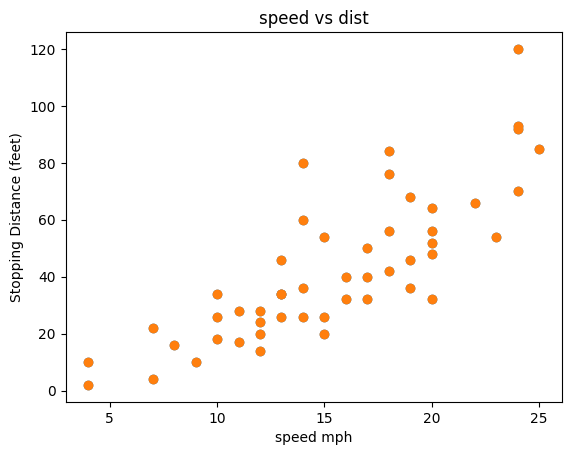

In [30]:
import matplotlib.pyplot as plt

X=df[["speed"]]
y=df["dist"]
plt.scatter(X,y)
plt.xlabel("speed mph")
plt.ylabel("Stopping Distance (feet)")
plt.title("speed vs dist")
plt.scatter(X,y)
plt

In [31]:
print(X_train.shape)
print(X_test.shape)
print(y_test.shape)
print(y_train.shape)

(40, 1)
(10, 1)
(10,)
(40,)


In [32]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)



In [33]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)
pred=model.predict(X_test)
pred

array([30.09436477, 59.57986283, 48.52280106, 74.32261186, 33.78005203,
       74.32261186, 44.8371138 , 41.15142654, 52.20848831, 37.46573929])

In [34]:
from sklearn.metrics import mean_absolute_error,r2_score

mae=mean_absolute_error(y_test,pred)
r2=r2_score(y_test,pred)
print("mae:",mae)
print("r2:",r2)

mae: 11.031431274322205
r2: 0.6157734182280231


In [43]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
x_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
pred_poly = model_poly.predict(x_test_poly)
pred_poly

array([28.65932536, 59.50272054, 46.94675497, 78.09143375, 32.05289332,
       78.09143375, 43.02535108, 39.23590618, 51.00011785, 35.57842026])

In [44]:
from sklearn.metrics import mean_absolute_error,r2_score

mae=mean_absolute_error(y_test,pred_poly)
r2=r2_score(y_test,pred_poly)
print("mae:",mae)
print("r2:",r2)

mae: 11.153014493321695
r2: 0.6588895099410288


In [45]:
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

model_poly3 = LinearRegression()
model_poly3.fit(X_train_poly3, y_train)

pred_poly3 = model_poly3.predict(X_test_poly3)

print("MAE:", mean_absolute_error(y_test, pred_poly3))
print("R2:", r2_score(y_test, pred_poly3))

MAE: 11.272627476941798
R2: 0.6746663290064945


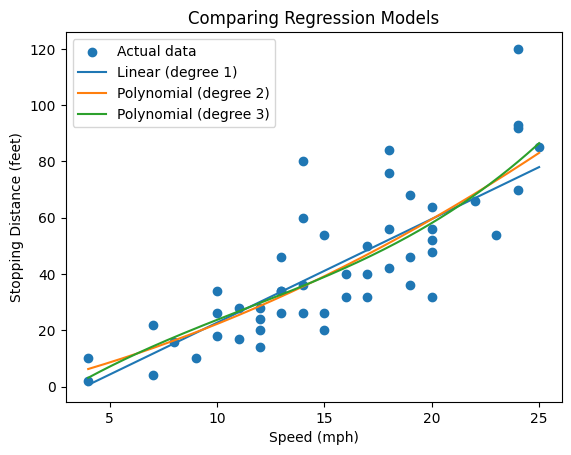

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Create smooth speed values for plotting
X_plot = pd.DataFrame({
    "speed": np.linspace(X["speed"].min(), X["speed"].max(), 300)
})

# Linear predictions (using 'model' instead of 'model_linear')
y_linear_plot = model.predict(X_plot)

# Degree 2 predictions
X_plot_poly2 = poly.transform(X_plot)
y_poly2_plot = model_poly.predict(X_plot_poly2)

# Degree 3 predictions
X_plot_poly3 = poly3.transform(X_plot)
y_poly3_plot = model_poly3.predict(X_plot_poly3)

# Plot
plt.scatter(X["speed"], y, label="Actual data")
plt.plot(X_plot["speed"], y_linear_plot, label="Linear (degree 1)")
plt.plot(X_plot["speed"], y_poly2_plot, label="Polynomial (degree 2)")
plt.plot(X_plot["speed"], y_poly3_plot, label="Polynomial (degree 3)")

plt.xlabel("Speed (mph)")
plt.ylabel("Stopping Distance (feet)")
plt.title("Comparing Regression Models")
plt.legend()
plt.show()

In [48]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

poly4 = PolynomialFeatures(degree=4)

X_train_poly4 = poly4.fit_transform(X_train)
X_test_poly4 = poly4.transform(X_test)

model_poly4 = LinearRegression()
model_poly4.fit(X_train_poly4, y_train)

pred_poly4 = model_poly4.predict(X_test_poly4)

print("MAE:", mean_absolute_error(y_test, pred_poly4))
print("R2:", r2_score(y_test, pred_poly4))

MAE: 11.16863016618328
R2: 0.6808963830392673


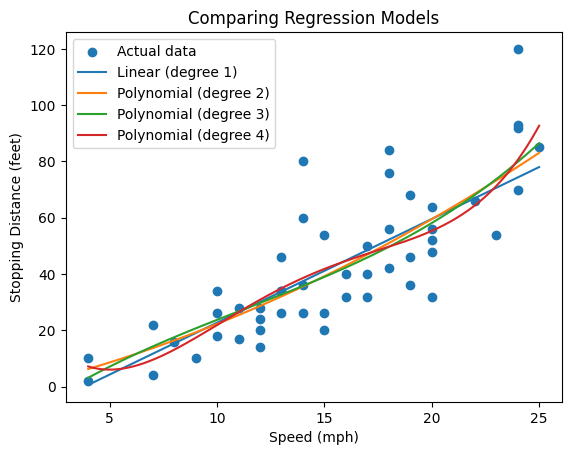

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X_plot = pd.DataFrame({
    "speed": np.linspace(X["speed"].min(), X["speed"].max(), 300)
})

y_linear_plot = model.predict(X_plot)

X_plot_poly2 = poly.transform(X_plot)
y_poly2_plot = model_poly.predict(X_plot_poly2)

X_plot_poly3 = poly3.transform(X_plot)
y_poly3_plot = model_poly3.predict(X_plot_poly3)

X_plot_poly4 = poly4.transform(X_plot)
y_poly4_plot = model_poly4.predict(X_plot_poly4)

plt.scatter(X["speed"], y, label="Actual data")
plt.plot(X_plot["speed"], y_linear_plot, label="Linear (degree 1)")
plt.plot(X_plot["speed"], y_poly2_plot, label="Polynomial (degree 2)")
plt.plot(X_plot["speed"], y_poly3_plot, label="Polynomial (degree 3)")
plt.plot(X_plot["speed"], y_poly4_plot, label="Polynomial (degree 4)")

plt.xlabel("Speed (mph)")
plt.ylabel("Stopping Distance (feet)")
plt.title("Comparing Regression Models")
plt.legend()
plt.show()

In [51]:
print("Degree 4 MAE:",
      mean_absolute_error(y_test, pred_poly4))

print("Degree 4 R2:",
      r2_score(y_test, pred_poly4))

Degree 4 MAE: 11.16863016618328
Degree 4 R2: 0.6808963830392673
